## TITANIC SURVIVAL PREDICTION

Description:
The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In [92]:
# importing the libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

In [93]:
# reading the dataset

boat_df = pd.read_csv('./Titanic-Dataset.csv')
boat_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [94]:
boat_df.sample(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
42,43,0,3,"Kraeff, Mr. Theodor",male,NaN,0,0,349253,7.8958,NaN,C
489,490,1,3,"Coutts, Master. Eden Leslie ""Neville""",male,9.0,1,1,C.A. 37671,15.9000,NaN,S
598,599,0,3,"Boulos, Mr. Hanna",male,NaN,0,0,2664,7.2250,NaN,C
818,819,0,3,"Holm, Mr. John Fredrik Alexander",male,43.0,0,0,C 7075,6.4500,NaN,S
599,600,1,1,"Duff Gordon, Sir. Cosmo Edmund (""Mr Morgan"")",male,49.0,1,0,PC 17485,56.9292,A20,C
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,NaN,C
128,129,1,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
532,533,0,3,"Elias, Mr. Joseph Jr",male,17.0,1,1,2690,7.2292,NaN,C


# reading the information about the dataset

In [95]:
boat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [96]:
round(boat_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.00,257.35,1.00,223.50,446.00,668.5,891.00
Survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00
Pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33


In [97]:
# checking for null values
boat_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Now I have to columns with null values i.e. 'Age','Cabin' and 'Embarked'

In [98]:
# first the 'cabin' column 
boat_df['Cabin'].sample(20)

331           C124
115            NaN
224            C93
84             NaN
404            NaN
643            NaN
765            D11
90             NaN
713            NaN
97         D10 D12
790            NaN
779             B3
586            NaN
637            NaN
447            NaN
624            NaN
371            NaN
878            NaN
28             NaN
679    B51 B53 B55
Name: Cabin, dtype: object

WE CANNOT GET MUCH INFORMATION FROM THE 'CABIN' COLUMN. I THINK IT IS BEST TO DROP IT

In [99]:
boat_df.drop('Cabin', inplace=True, axis = 1)

In [100]:
boat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [101]:
# NOW THE EMBARKED COLUMN
boat_df['Embarked']

# as we know there is only one null value so it is best to fill the value with the most common term used in the column

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [102]:
boat_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [103]:
boat_df['Embarked'].fillna('S',inplace=True)

In [104]:
boat_df['Embarked'].isna().sum()

np.int64(0)

In [105]:
# NOW THE AGE COLUMN
boat_df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [106]:
# as we can see the dataset have a little bit of outliers like 0 and 80. So, it is preferred to use median() here

boat_df['Age'] = boat_df['Age'].fillna(boat_df['Age'].median())

In [107]:
boat_df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

The things that we do next are :
* We can remove the name , ticket and passenger ID column because it is not necessary to train our model on it
* we can combine the siblings and parent column into one column like no. of family members
* we can turn the embarked column into numeric 
* we have to turn the sex column into int

In [108]:
#  droping the name column
boat_df.drop('Name',inplace = True, axis = 1)

In [131]:
boat_df.drop('Ticket', inplace = True, axis = 1)

In [109]:
# dropping the id column
boat_df.drop('PassengerId', inplace = True , axis = 1)

In [110]:
# combining the column
boat_df['Num_of_Family'] = boat_df['SibSp'] + boat_df['Parch']

In [111]:
# now droping those two columns 
boat_df.drop(['SibSp','Parch'], inplace = True, axis = 1)

In [112]:
# Mapping the embarked column 
boat_df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [113]:
boat_df = pd.get_dummies(boat_df, columns=['Embarked'], drop_first=True)

In [115]:
boat_df[['Embarked_Q','Embarked_S']] = boat_df[['Embarked_Q','Embarked_S']].astype(int)

In [133]:
boat_df.Sex.unique()

array(['male', 'female'], dtype=object)

In [134]:
gender_code = {'male' : 0, 'female' : 1}
boat_df['gender_code'] = boat_df.Sex.map(gender_code)

In [137]:
boat_df.drop('Sex',inplace = True , axis = 1)

In [138]:
boat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Age            891 non-null    float64
 3   Fare           891 non-null    float64
 4   Num_of_Family  891 non-null    int64  
 5   Embarked_Q     891 non-null    int64  
 6   Embarked_S     891 non-null    int64  
 7   gender_code    891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


## TRAINING THE MODEL 

In [139]:
# SPLITING THE DATA SET INTO INPUT COLUMNS AND TARGETS COLUMNS 

X = boat_df.drop('Survived',axis = 1) #input
Y = boat_df['Survived'] # output

In [140]:
# training the dataset into training and testing

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,random_state=42,test_size=0.25)

In [141]:
# Scaling turns the dataset into small numerical values between 0 and 1 

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [146]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [154]:
# CREATING A FUNCTION TO TEST DIFFERENT MODELS

def train_model(model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    predictions = model.predict(X_test)
    cm = confusion_matrix(Y_test,predictions)
    plt.title('Confusion Matrix')
    sns.heatmap(cm,annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return {
        "model": model.__class__.__name__,

        "accuracy": accuracy_score(Y_test, predictions),
        
        'Cm' : confusion_matrix(Y_test,predictions)
    }

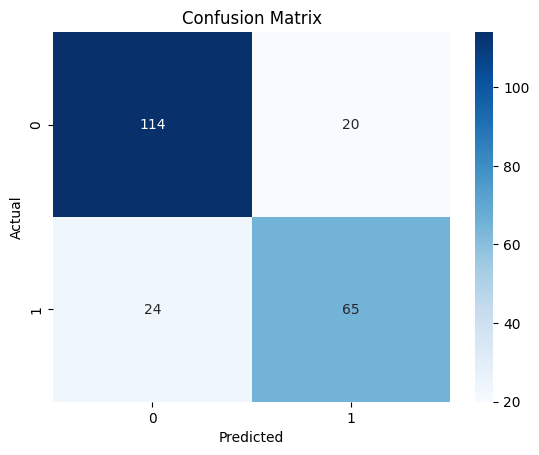

{'model': 'LogisticRegression',
 'accuracy': 0.8026905829596412,
 'Cm': array([[114,  20],
        [ 24,  65]])}

In [155]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
train_model(model, X_train, Y_train, X_test, Y_test)

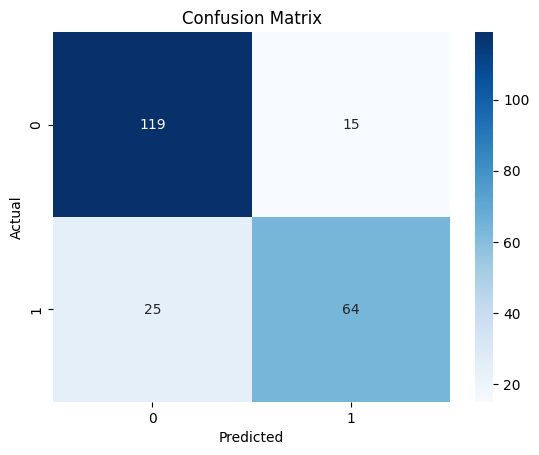

{'model': 'DecisionTreeClassifier',
 'accuracy': 0.820627802690583,
 'Cm': array([[119,  15],
        [ 25,  64]])}

In [156]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=7, random_state=42)
train_model(model, X_train, Y_train, X_test, Y_test)

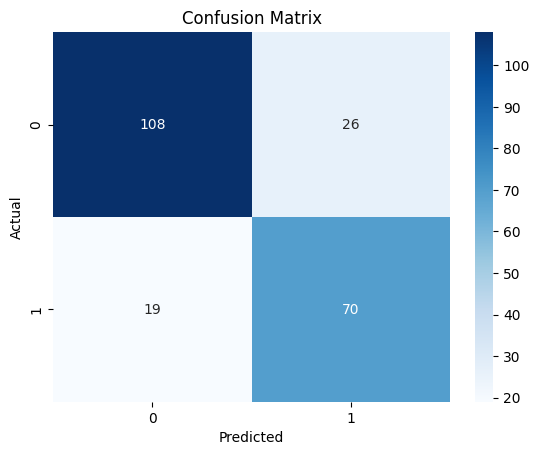

{'model': 'RandomForestClassifier',
 'accuracy': 0.7982062780269058,
 'Cm': array([[108,  26],
        [ 19,  70]])}

In [157]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=10)
train_model(model, X_train, Y_train, X_test, Y_test)